# ============================================================
# Task 2: Exploratory Data Analysis (EDA) – Titanic Dataset
# Tools: Pandas, Matplotlib, Seaborn
# ============================================================


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import io
import os

In [3]:
warnings.filterwarnings("ignore")

In [4]:
# ── Style ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.family": "DejaVu Sans"})
os.makedirs("plots", exist_ok=True)

# ============================================================
# 1. LOAD / CREATE DATASET
# ============================================================

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")
print("✅ Dataset ready:", df.shape)

✅ Dataset ready: (891, 12)


# ============================================================
# 2. BASIC INSPECTION
# ============================================================

In [10]:
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(df.head())
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


DATASET OVERVIEW
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

# ============================================================
# 3. SUMMARY STATISTICS
# ============================================================

In [12]:
print("\n" + "="*60)
print("SUMMARY STATISTICS (Numeric Features)")
print("="*60)
print(df.describe().round(2).to_string())

print("\n" + "="*60)
print("SUMMARY STATISTICS (Categorical Features)")
print("="*60)
for col in ["Sex", "Pclass", "Embarked", "Survived"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

# ── Skewness & Kurtosis ──────────────────────────────────────
numeric = ["Age", "Fare", "SibSp", "Parch"]
print("\n" + "="*60)
print("SKEWNESS & KURTOSIS")
print("="*60)
for col in numeric:
    sk = df[col].skew()
    ku = df[col].kurt()
    skew_type = "Right-skewed" if sk > 0.5 else ("Left-skewed" if sk < -0.5 else "Approx. normal")
    print(f"  {col:8s} | Skewness: {sk:6.3f} ({skew_type}) | Kurtosis: {ku:.3f}")


SUMMARY STATISTICS (Numeric Features)
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33

SUMMARY STATISTICS (Categorical Features)

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Survived:
Survived
0    549
1    342
Name: count, dtype: int64

SKEWNESS & KURTOSIS
  Age 

# ============================================================
# 4. VISUALISATIONS
# ============================================================

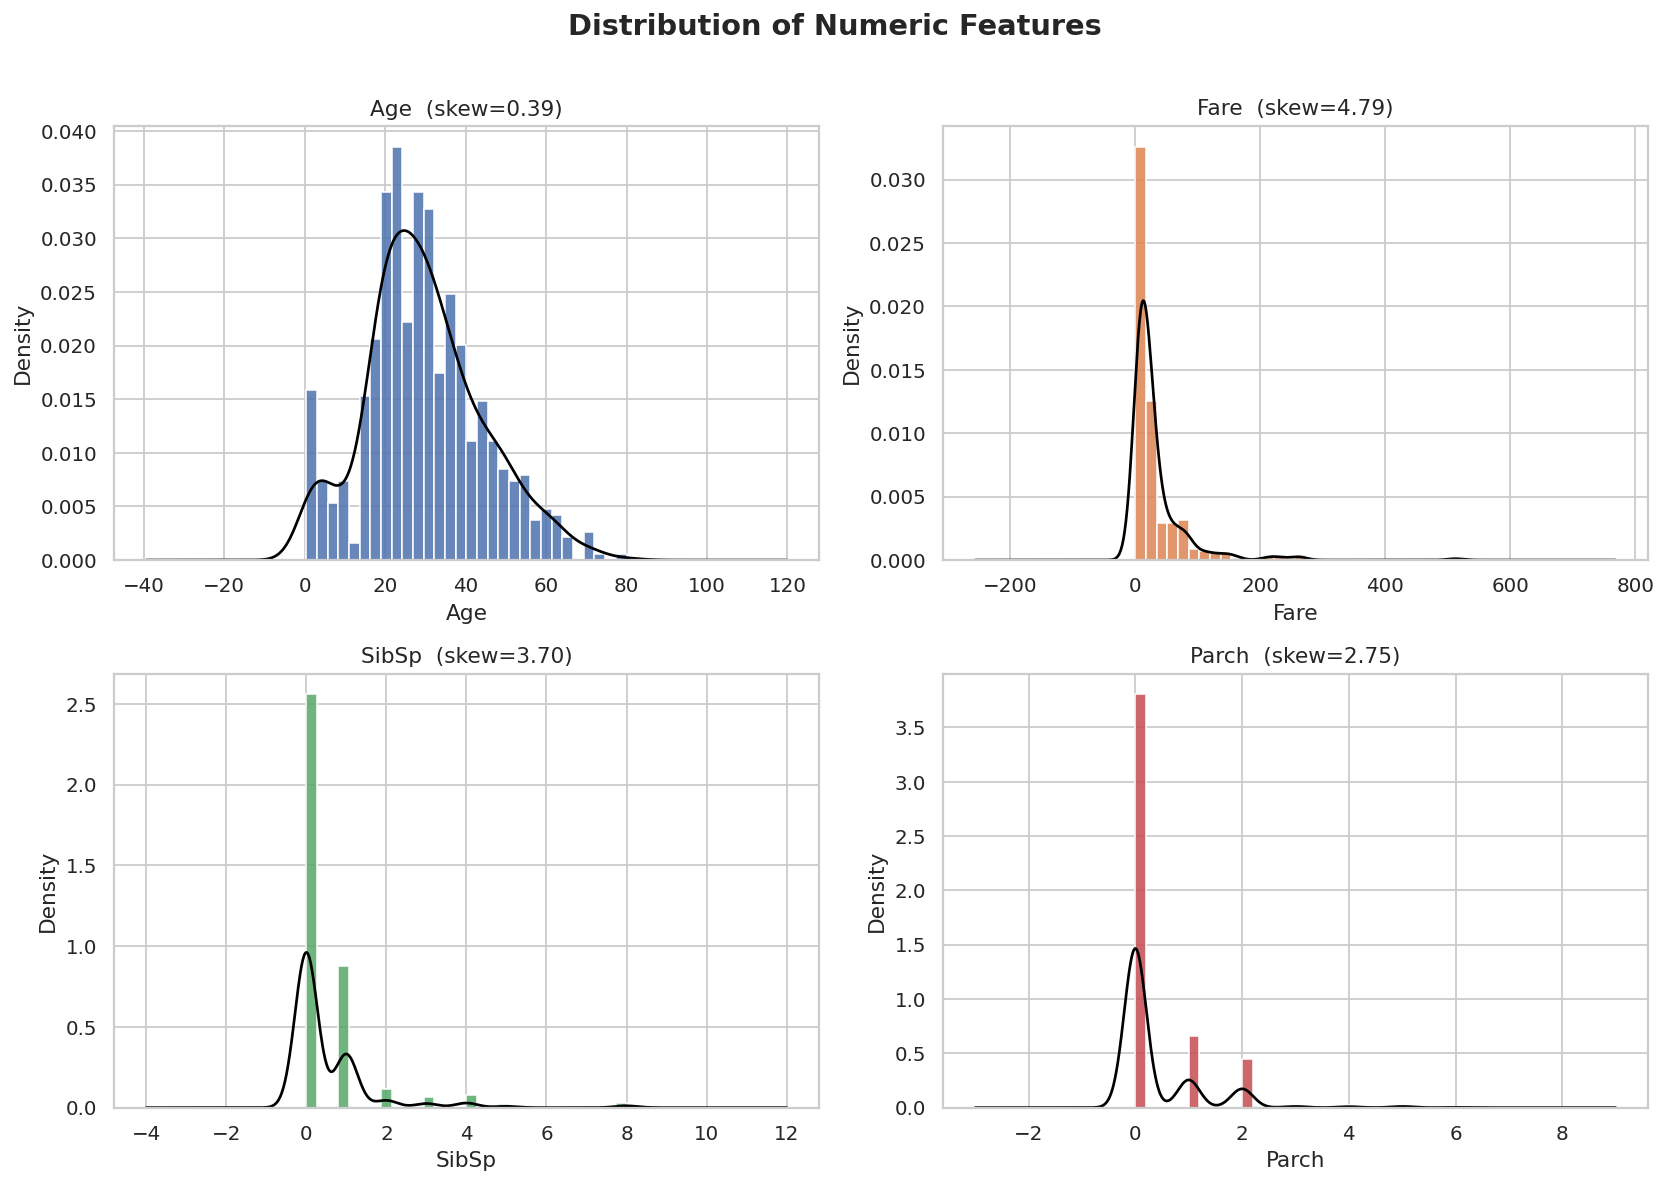


✅ Saved: plots/01_histograms.png


In [25]:
%matplotlib inline
# ── 4a. Distribution plots (Histograms + KDE) ───────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Distribution of Numeric Features", fontsize=16, fontweight="bold", y=1.01)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for ax, col, color in zip(axes.flatten(), numeric, colors):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor="white", alpha=0.85, density=True)
    df[col].dropna().plot.kde(ax=ax, color="black", lw=1.5)
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})", fontsize=12)
    ax.set_xlabel(col); ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig("plots/01_histograms.png", bbox_inches="tight")
plt.show()
plt.close()
print("\n✅ Saved: plots/01_histograms.png")


✅ Saved: plots/02_boxplots.png


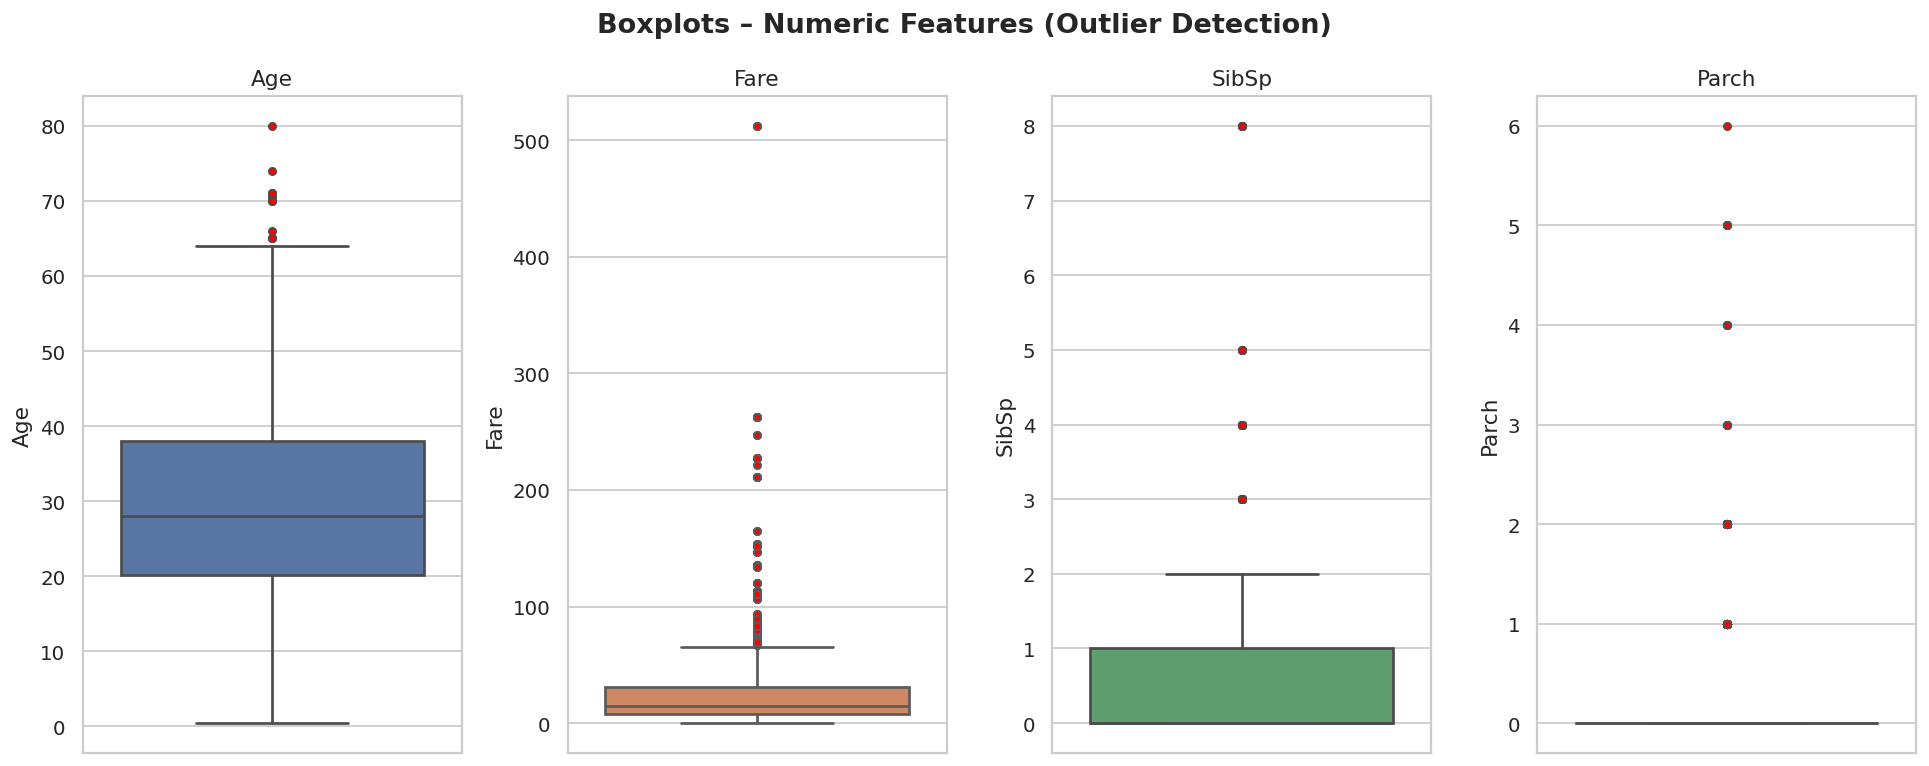

In [27]:
# ── 4b. Boxplots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 6))
fig.suptitle("Boxplots – Numeric Features (Outlier Detection)", fontsize=15, fontweight="bold")
for ax, col, color in zip(axes, numeric, colors):
    sns.boxplot(y=df[col], ax=ax, color=color, flierprops=dict(marker="o", markerfacecolor="red", markersize=4))
    ax.set_title(col, fontsize=12)
plt.tight_layout()
plt.savefig("plots/02_boxplots.png", bbox_inches="tight")
print("✅ Saved: plots/02_boxplots.png")
plt.show()
plt.close()

✅ Saved: plots/03_survival_by_category.png


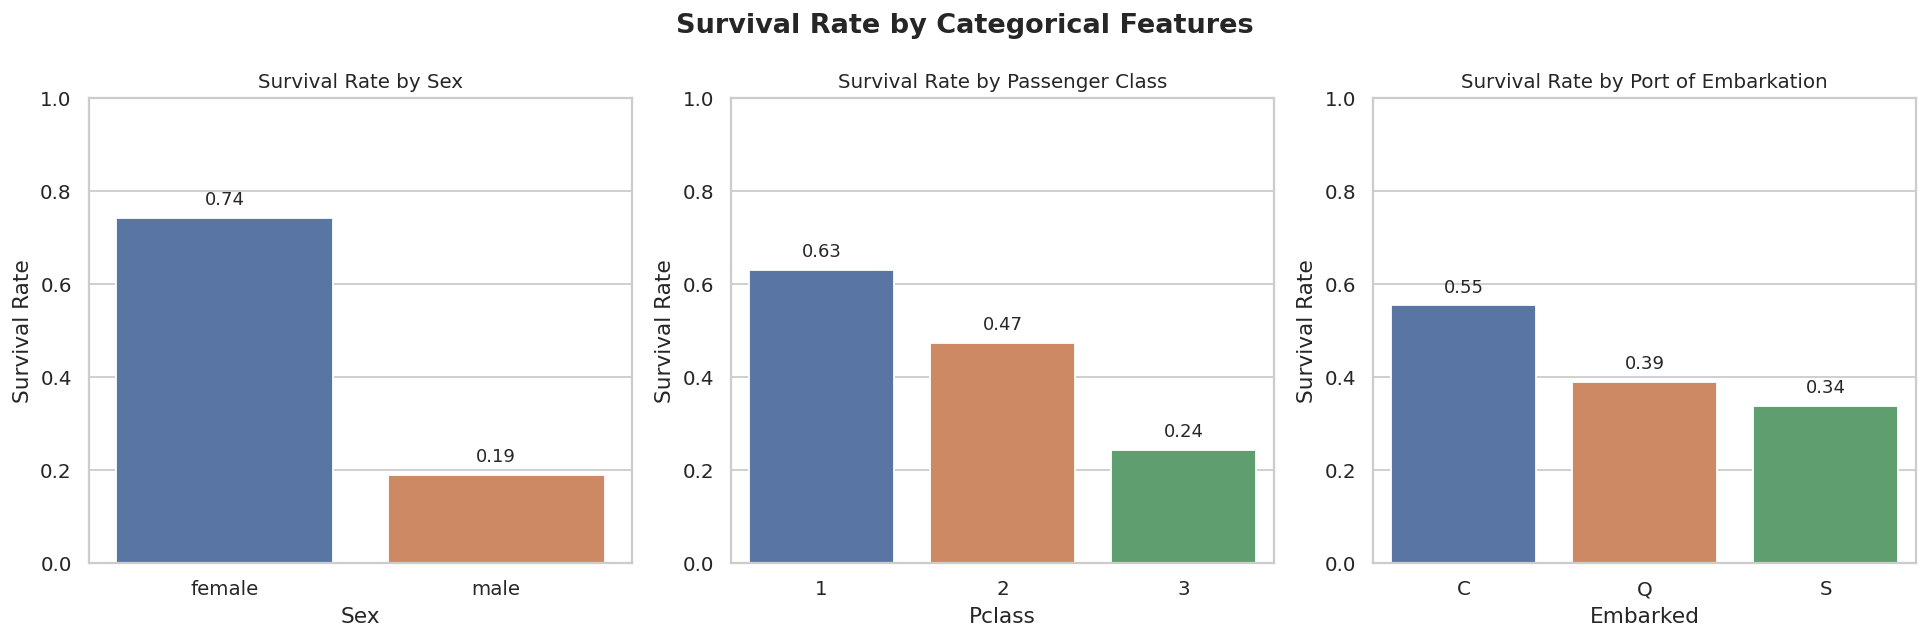

In [28]:
# ── 4c. Survival by Category (Bar Charts) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Survival Rate by Categorical Features", fontsize=15, fontweight="bold")

cat_feats = [("Sex", "Sex"), ("Pclass", "Passenger Class"), ("Embarked", "Port of Embarkation")]
for ax, (col, label) in zip(axes, cat_feats):
    surv = df.groupby(col)["Survived"].mean().reset_index()
    sns.barplot(data=surv, x=col, y="Survived", ax=ax, palette="deep", edgecolor="white")
    ax.set_title(f"Survival Rate by {label}", fontsize=11)
    ax.set_ylabel("Survival Rate")
    ax.set_ylim(0, 1)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("plots/03_survival_by_category.png", bbox_inches="tight")
print("✅ Saved: plots/03_survival_by_category.png")
plt.show()
plt.close()

✅ Saved: plots/04_correlation_matrix.png


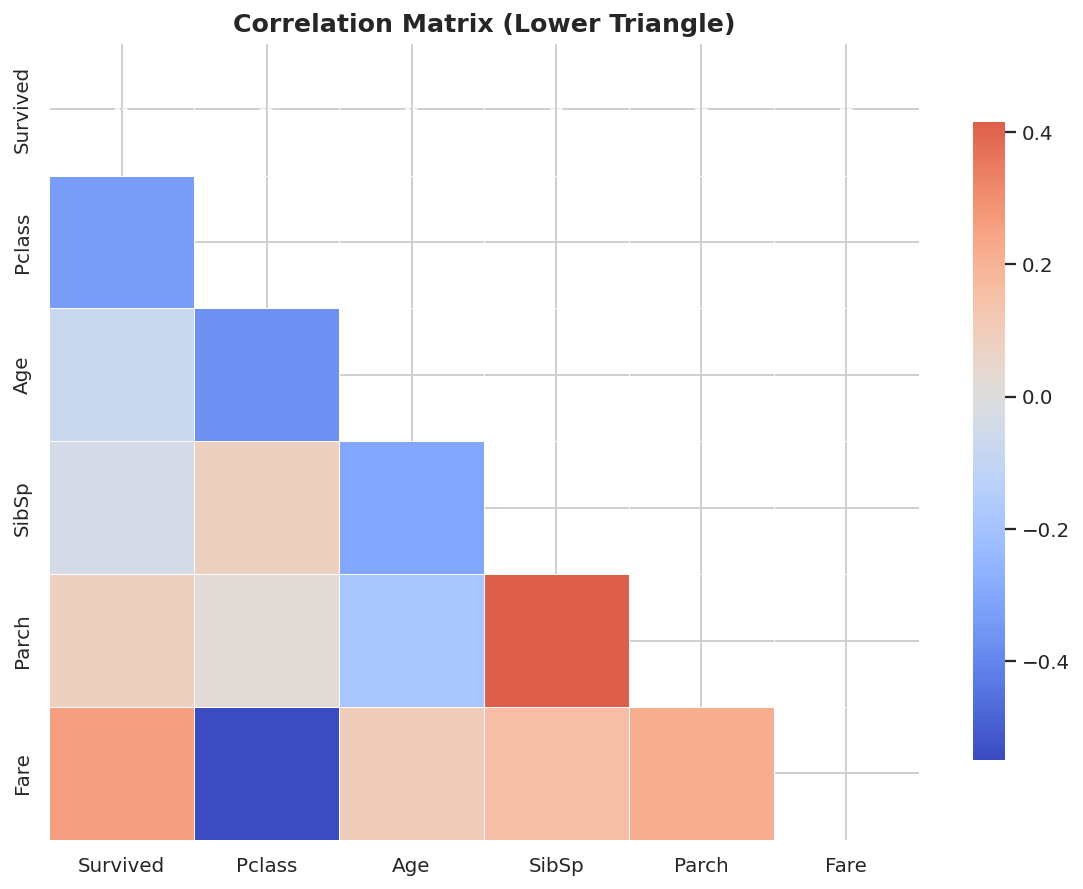

In [29]:
# ── 4d. Correlation Matrix ───────────────────────────────────
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size": 11},
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix (Lower Triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/04_correlation_matrix.png", bbox_inches="tight")
print("✅ Saved: plots/04_correlation_matrix.png")
plt.show()
plt.close()

✅ Saved: plots/05_age_survival_sex.png


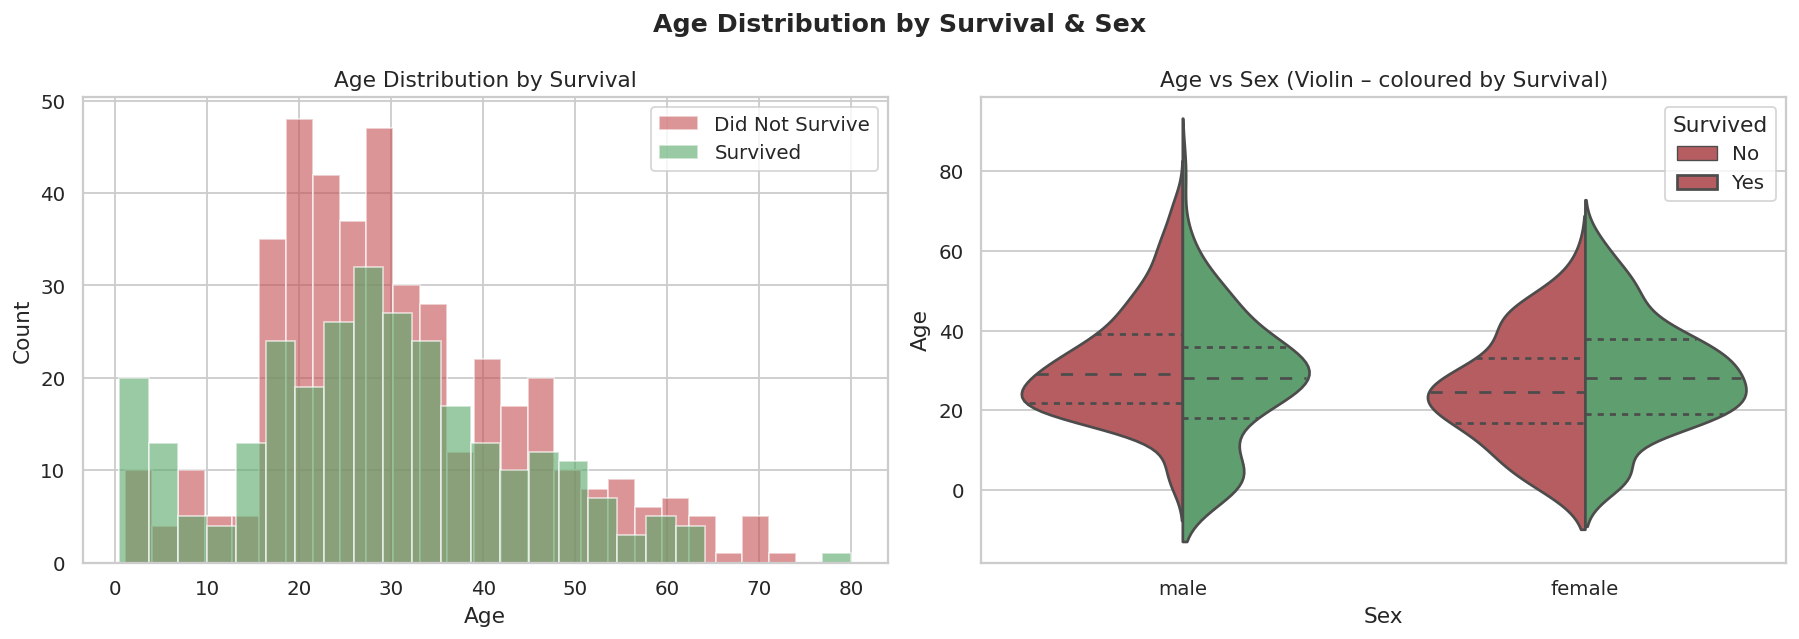

In [30]:
# ── 4e. Age distribution by Survived & Sex ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Age Distribution by Survival & Sex", fontsize=14, fontweight="bold")

for val, label, color in [(0, "Did Not Survive", "#C44E52"), (1, "Survived", "#55A868")]:
    axes[0].hist(df[df["Survived"] == val]["Age"].dropna(), bins=25, alpha=0.6, label=label, color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Survival"); axes[0].legend(); axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")

sns.violinplot(data=df, x="Sex", y="Age", hue="Survived", split=True, ax=axes[1],
               palette={0: "#C44E52", 1: "#55A868"}, inner="quart")
axes[1].set_title("Age vs Sex (Violin – coloured by Survival)")
axes[1].legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("plots/05_age_survival_sex.png", bbox_inches="tight")
print("✅ Saved: plots/05_age_survival_sex.png")
plt.show()
plt.close()

✅ Saved: plots/06_fare_analysis.png


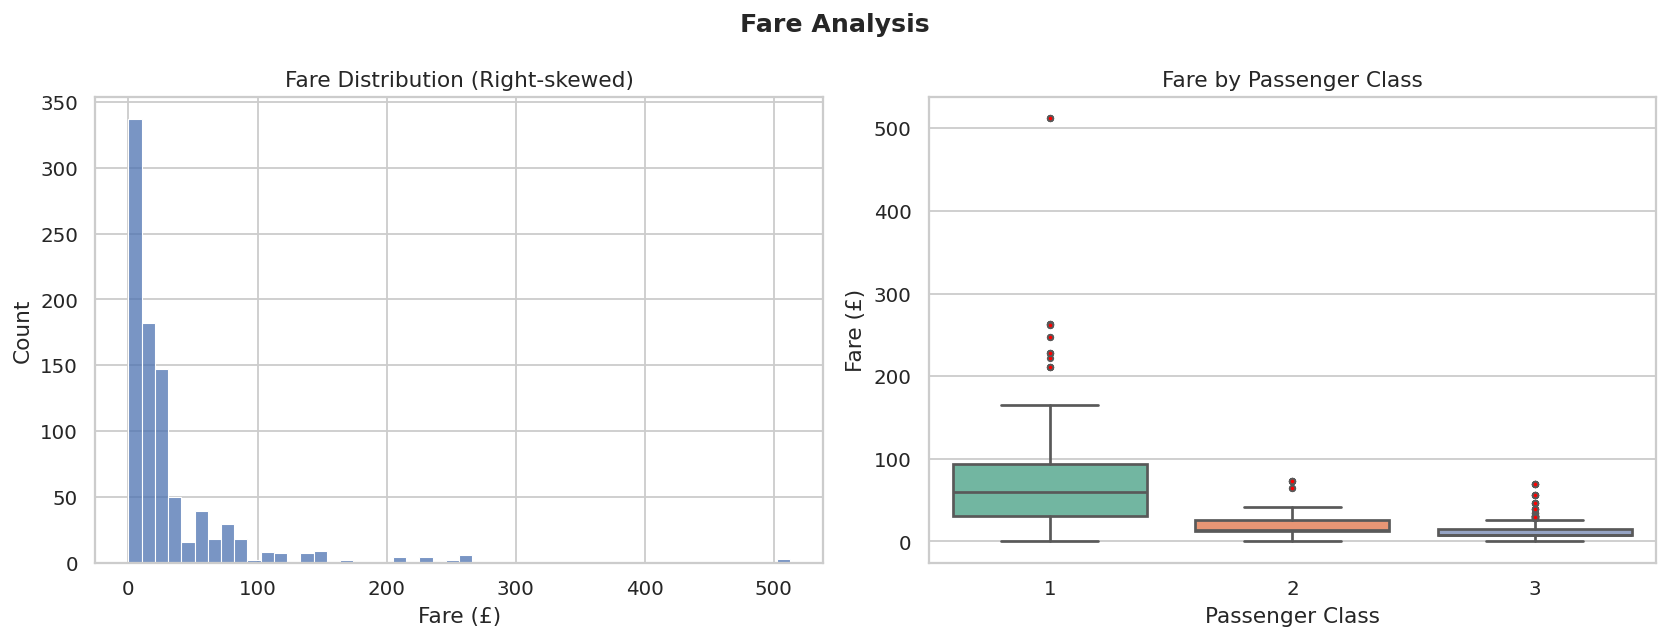

In [31]:
# ── 4f. Fare distribution & outliers ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fare Analysis", fontsize=14, fontweight="bold")

sns.histplot(df["Fare"], bins=50, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Fare Distribution (Right-skewed)")
axes[0].set_xlabel("Fare (£)")

sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[1], palette="Set2",
            flierprops=dict(marker="o", markerfacecolor="red", markersize=3))
axes[1].set_title("Fare by Passenger Class")
axes[1].set_xlabel("Passenger Class"); axes[1].set_ylabel("Fare (£)")
plt.tight_layout()
plt.savefig("plots/06_fare_analysis.png", bbox_inches="tight")
print("✅ Saved: plots/06_fare_analysis.png")
plt.show()
plt.close()

✅ Saved: plots/07_pairplot.png


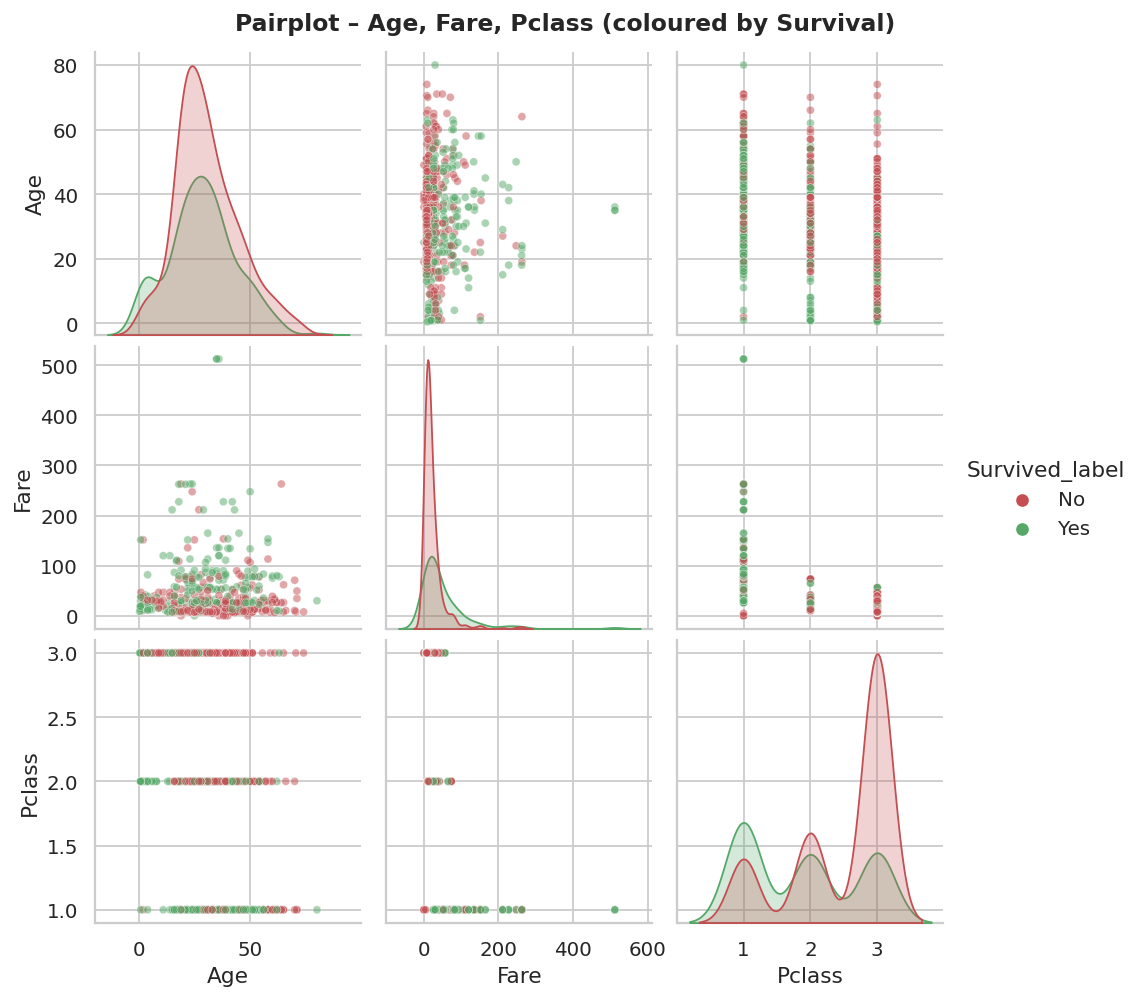

In [32]:
# ── 4g. Pairplot (key features) ─────────────────────────────
pair_df = df[["Age", "Fare", "Pclass", "Survived"]].dropna()
pair_df["Survived_label"] = pair_df["Survived"].map({0: "No", 1: "Yes"})
g = sns.pairplot(pair_df, hue="Survived_label", palette={"No": "#C44E52", "Yes": "#55A868"},
                 diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20},
                 vars=["Age", "Fare", "Pclass"])
g.fig.suptitle("Pairplot – Age, Fare, Pclass (coloured by Survival)", y=1.02, fontsize=13, fontweight="bold")
g.fig.savefig("plots/07_pairplot.png", bbox_inches="tight")
print("✅ Saved: plots/07_pairplot.png")
plt.show()
plt.close()

✅ Saved: plots/08_missing_values.png


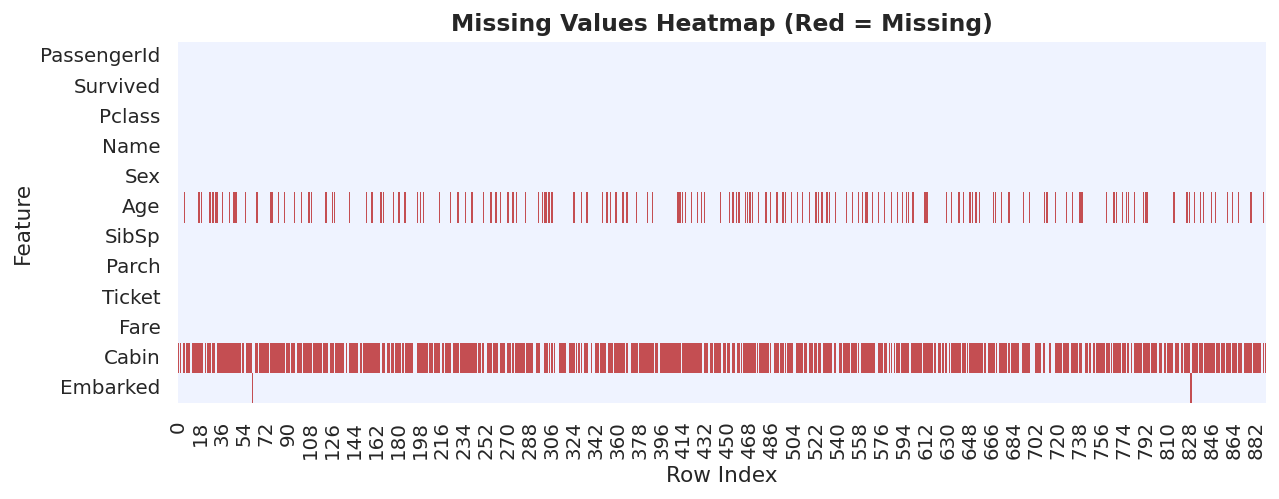

In [33]:
# ── 4h. Missing values heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
missing_df = df.isnull().astype(int)
sns.heatmap(missing_df.T, cmap=["#EFF3FF", "#C44E52"], cbar=False, ax=ax, yticklabels=df.columns)
ax.set_title("Missing Values Heatmap (Red = Missing)", fontsize=13, fontweight="bold")
ax.set_xlabel("Row Index"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("plots/08_missing_values.png", bbox_inches="tight")
print("✅ Saved: plots/08_missing_values.png")
plt.show()
plt.close()

✅ Saved: plots/09_class_survival_count.png


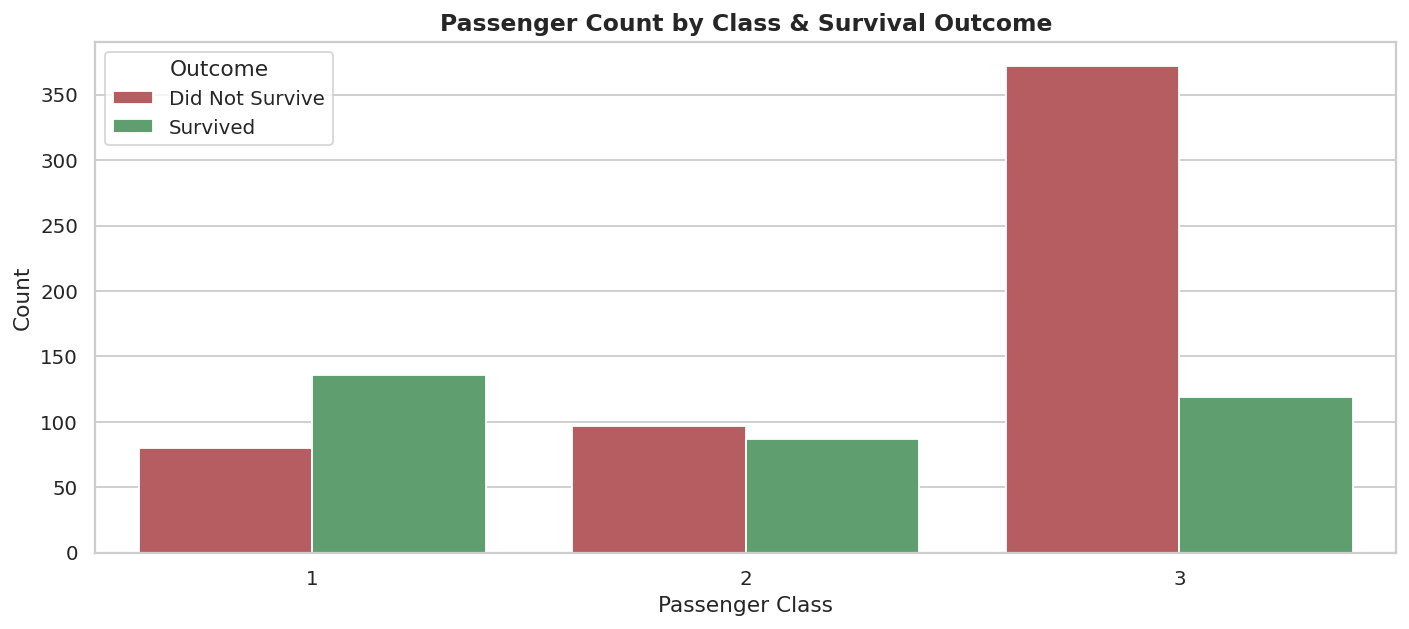

In [34]:
# ── 4i. Count plot: Class × Sex × Survival ──────────────────
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = df.copy()
plot_df["Survived_label"] = plot_df["Survived"].map({0: "Did Not Survive", 1: "Survived"})
sns.countplot(data=plot_df, x="Pclass", hue="Survived_label", palette={"Did Not Survive": "#C44E52", "Survived": "#55A868"},
              ax=ax, edgecolor="white")
ax.set_title("Passenger Count by Class & Survival Outcome", fontsize=13, fontweight="bold")
ax.set_xlabel("Passenger Class"); ax.set_ylabel("Count")
ax.legend(title="Outcome")
plt.tight_layout()
plt.savefig("plots/09_class_survival_count.png", bbox_inches="tight")
print("✅ Saved: plots/09_class_survival_count.png")
plt.show()
plt.close()

# ============================================================
# 5. KEY INFERENCES SUMMARY
# ============================================================

In [22]:
print("\n" + "="*60)
print("KEY INFERENCES FROM EDA")
print("="*60)
female_surv = df[df["Sex"] == "female"]["Survived"].mean()
male_surv   = df[df["Sex"] == "male"]["Survived"].mean()
c1_surv     = df[df["Pclass"] == 1]["Survived"].mean()
c3_surv     = df[df["Pclass"] == 3]["Survived"].mean()
fare_q99    = df["Fare"].quantile(0.99)
age_missing = df["Age"].isnull().mean() * 100
fare_corr   = df["Fare"].corr(df["Survived"])
pclass_corr = df["Pclass"].corr(df["Survived"])

print(f"\n1. Survival Rate (overall):         {df['Survived'].mean():.1%}")
print(f"   Female survival rate:             {female_surv:.1%}")
print(f"   Male   survival rate:             {male_surv:.1%}")
print(f"\n2. Class 1 survival rate:            {c1_surv:.1%}")
print(f"   Class 3 survival rate:            {c3_surv:.1%}")
print(f"\n3. Age has {age_missing:.1f}% missing values → needs imputation.")
print(f"\n4. Fare is right-skewed (skew={df['Fare'].skew():.2f}); outliers above £{fare_q99:.0f}.")
print(f"\n5. Fare ↔ Survived correlation:      {fare_corr:.3f} (positive)")
print(f"   Pclass ↔ Survived correlation:   {pclass_corr:.3f} (negative → lower class = less survival)")
print(f"\n6. SibSp & Parch are heavily zero-inflated → right-skewed distributions.")
print(f"\n7. Embarked has only {df['Embarked'].isnull().sum()} missing value(s) → easy to impute with mode.")
print(f"\n8. No duplicate rows detected.")
print("\n" + "="*60)
print("EDA COMPLETE  ✅  All plots saved to ./plots/")
print("="*60)


KEY INFERENCES FROM EDA

1. Survival Rate (overall):         38.4%
   Female survival rate:             74.2%
   Male   survival rate:             18.9%

2. Class 1 survival rate:            63.0%
   Class 3 survival rate:            24.2%

3. Age has 19.9% missing values → needs imputation.

4. Fare is right-skewed (skew=4.79); outliers above £249.

5. Fare ↔ Survived correlation:      0.257 (positive)
   Pclass ↔ Survived correlation:   -0.338 (negative → lower class = less survival)

6. SibSp & Parch are heavily zero-inflated → right-skewed distributions.

7. Embarked has only 2 missing value(s) → easy to impute with mode.

8. No duplicate rows detected.

EDA COMPLETE  ✅  All plots saved to ./plots/
